- Câu hỏi: Số lượng ảnh (image_count) và video (video_count) có ảnh hưởng đến số lượng bán ra  (quantity_sold) không? 
- Lợi ích của câu hỏi: 
+ Tối ưu nội dung sản phẩm: Nếu ảnh hưởng rõ ràng → seller biết họ cần thêm bao nhiêu ảnh/video để cải thiện doanh số.
+ Các mô hình gợi ý có thể ưu tiên sản phẩm có visual tốt / visual nhiều,...
+ Định hướng chiến lược truyền thông: 
Nếu video không tác động nhiều → seller tiết kiệm thời gian/chi phí sản xuất video.
Nếu hình ảnh có tác động → họ nên đầu tư vào minh họa góc nhìn đa chiều.
- Cách tìm câu trả lời:
+ Bước 1: Thống kê mô tả các dữ liệu liên quan đến hình ảnh, video và biến mục tiêu quantity_sold
+ Bước 2: Vẽ biểu đồ histogram/box plot cho từng biến liên quan đến hình ảnh, video và biến mục tiêu quantity_sold để xem phân phối dữ liệu
+ Bước 3: Trực quan mối quan hệ giữa các biến liên quan đến hình ảnh, video và biến mục tiêu quantity_sold bằng Scatter Plot + Regression Line(giữa từng biến video_count, image_count, total_visuals với quantity_sold) để thấy được hệ số tương quan r; bằng Violin Plot để so sánh lượt bán ra của có video và không có video chênh lệch nhiều không; bằng Heatmap để xem độ tương quan giữa các các biến liên quan đến hình ảnh, video và biến mục tiêu quantity_sold.

1. Import thư viện và đọc dữ liệu

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Đọc dữ liệu
df = pd.read_csv('full_data_final.csv')

# Tạo DataFrame chỉ với các biến cần phân tích
visual_vars = ['image_count', 'video_count', 'total_visuals', 'has_video', 'quantity_sold']
df_visual = df[visual_vars].copy()

print(" Đã đọc dữ liệu thành công!")
print(f"Kích thước dữ liệu: {df_visual.shape}")
print(f"Các biến khảo sát: {list(df_visual.columns)}")

 Đã đọc dữ liệu thành công!
Kích thước dữ liệu: (19811, 5)
Các biến khảo sát: ['image_count', 'video_count', 'total_visuals', 'has_video', 'quantity_sold']


2. Thống kê mô tả

In [2]:

print("="*80)
print("THỐNG KÊ MÔ TẢ CÁC BIẾN")
print("="*80)

stats_desc = df_visual.describe().transpose()
stats_desc['median'] = df_visual.median()
stats_desc = stats_desc[['count', 'mean', 'median', 'std', 'min', 'max']]
print(stats_desc.round(3))

print("\n Tỷ lệ sản phẩm có video (has_video = 1):")
print(f"{df_visual['has_video'].mean():.1%}")
print(f"Số lượng: {df_visual['has_video'].sum():.0f} / {len(df_visual)}")

print("\n Tỷ lệ sản phẩm không có ảnh (image_count = 0):")
print(f"{(df_visual['image_count'] == 0).mean():.1%}")

print("\n Tỷ lệ sản phẩm không bán được (quantity_sold = 0):")
print(f"{(df_visual['quantity_sold'] == 0).mean():.1%}")

THỐNG KÊ MÔ TẢ CÁC BIẾN
                 count   mean  median    std  min     max
image_count    19811.0  5.689   5.000  3.576  1.0  18.000
video_count    19811.0  0.342   0.000  0.964  0.0   4.382
total_visuals  19811.0  6.031   5.693  3.808  1.0  22.382
has_video      19811.0  0.226   0.000  0.419  0.0   1.000
quantity_sold  19811.0  2.317   1.792  2.300  0.0   9.170

 Tỷ lệ sản phẩm có video (has_video = 1):
22.6%
Số lượng: 4487 / 19811

 Tỷ lệ sản phẩm không có ảnh (image_count = 0):
0.0%

 Tỷ lệ sản phẩm không bán được (quantity_sold = 0):
28.5%


3. Phân phối dữ liệu (biểu đồ)


PHÂN PHỐI DỮ LIỆU


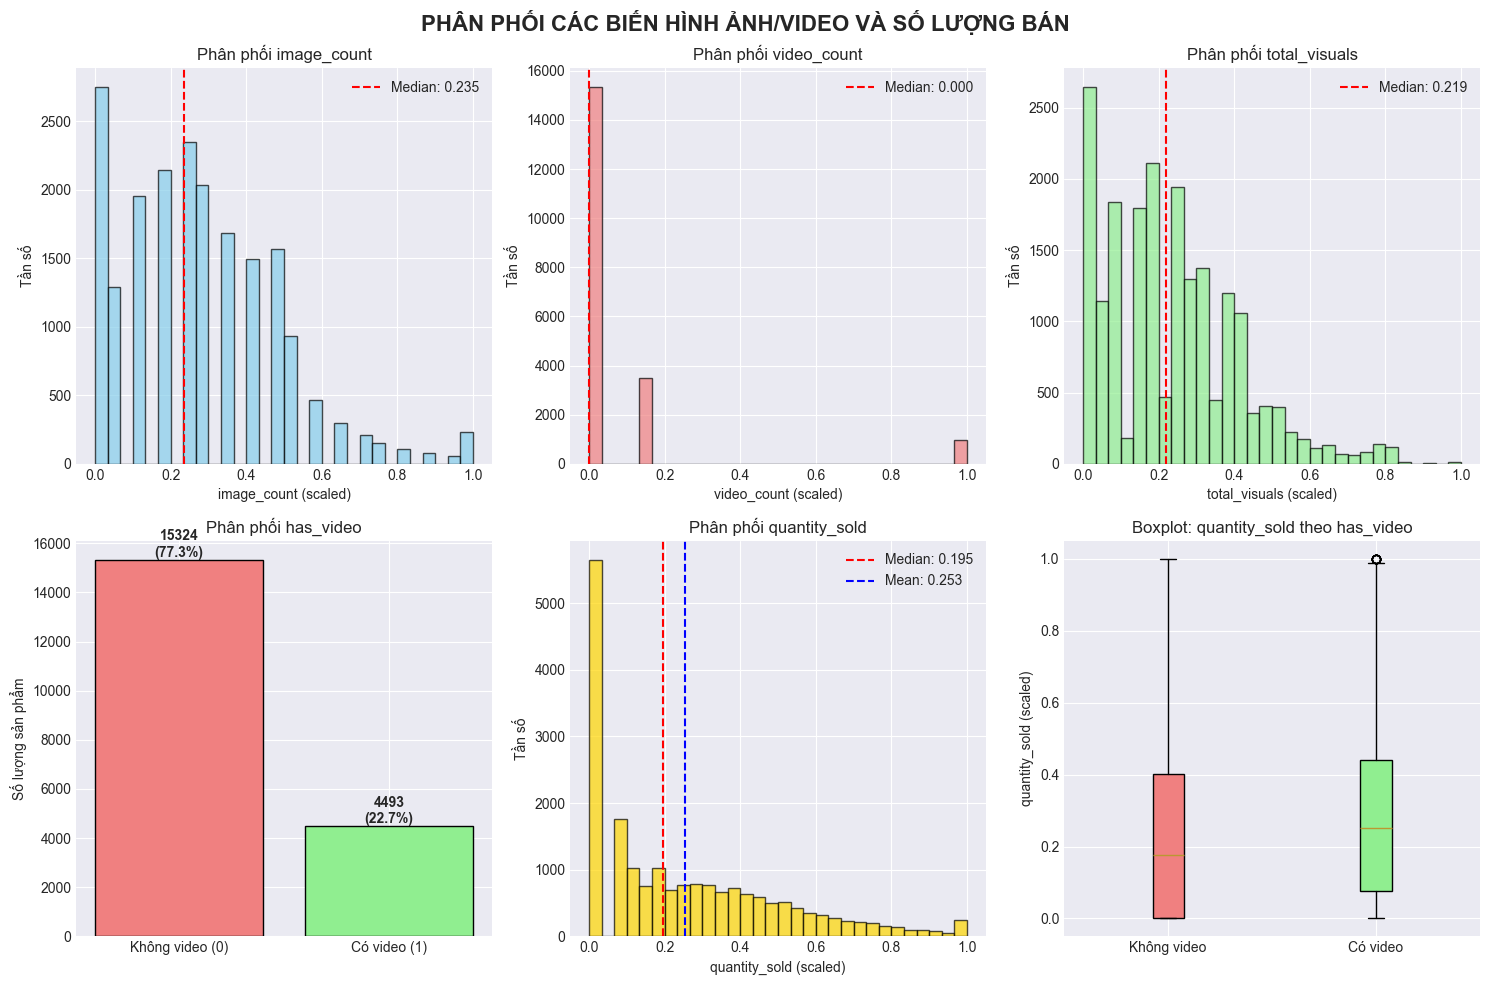

In [ ]:

print("\n" + "="*80)
print("PHÂN PHỐI DỮ LIỆU")
print("="*80)

# Tạo figure với các subplot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('PHÂN PHỐI CÁC BIẾN HÌNH ẢNH/VIDEO VÀ SỐ LƯỢNG BÁN', fontsize=16, fontweight='bold')

# Phân phối image_count
axes[0, 0].hist(df_visual['image_count'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(df_visual['image_count'].median(), color='red', linestyle='--', label=f'Median: {df_visual["image_count"].median():.3f}')
axes[0, 0].set_title('Phân phối image_count')
axes[0, 0].set_xlabel('image_count (scaled)')
axes[0, 0].set_ylabel('Tần số')
axes[0, 0].legend()

# Phân phối video_count
axes[0, 1].hist(df_visual['video_count'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].axvline(df_visual['video_count'].median(), color='red', linestyle='--', label=f'Median: {df_visual["video_count"].median():.3f}')
axes[0, 1].set_title('Phân phối video_count')
axes[0, 1].set_xlabel('video_count (scaled)')
axes[0, 1].set_ylabel('Tần số')
axes[0, 1].legend()

# Phân phối total_visuals
axes[0, 2].hist(df_visual['total_visuals'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 2].axvline(df_visual['total_visuals'].median(), color='red', linestyle='--', label=f'Median: {df_visual["total_visuals"].median():.3f}')
axes[0, 2].set_title('Phân phối total_visuals')
axes[0, 2].set_xlabel('total_visuals (scaled)')
axes[0, 2].set_ylabel('Tần số')
axes[0, 2].legend()

# Phân phối has_video
has_video_counts = df_visual['has_video'].value_counts()
bars = axes[1, 0].bar(['Không video (0)', 'Có video (1)'], has_video_counts.values, 
               color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[1, 0].set_title('Phân phối has_video')
axes[1, 0].set_ylabel('Số lượng sản phẩm')

# Thêm số trên mỗi cột
for i, (bar, v) in enumerate(zip(bars, has_video_counts.values)):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 5,
                   f'{v}\n({v/len(df_visual)*100:.1f}%)',
                   ha='center', va='bottom', fontweight='bold')

# Phân phối quantity_sold
axes[1, 1].hist(df_visual['quantity_sold'], bins=30, edgecolor='black', alpha=0.7, color='gold')
axes[1, 1].axvline(df_visual['quantity_sold'].median(), color='red', linestyle='--', label=f'Median: {df_visual["quantity_sold"].median():.3f}')
axes[1, 1].axvline(df_visual['quantity_sold'].mean(), color='blue', linestyle='--', label=f'Mean: {df_visual["quantity_sold"].mean():.3f}')
axes[1, 1].set_title('Phân phối quantity_sold')
axes[1, 1].set_xlabel('quantity_sold (scaled)')
axes[1, 1].set_ylabel('Tần số')
axes[1, 1].legend()

# Boxplot quantity_sold theo has_video
box_data = [df_visual[df_visual['has_video'] == 0]['quantity_sold'],
            df_visual[df_visual['has_video'] == 1]['quantity_sold']]
bp = axes[1, 2].boxplot(box_data, labels=['Không video', 'Có video'], patch_artist=True)
colors = ['lightcoral', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1, 2].set_title('Boxplot: quantity_sold theo has_video')
axes[1, 2].set_ylabel('quantity_sold (scaled)')

plt.tight_layout()
plt.show()

4. Ma trận tương quan giữa các biến


TƯƠNG QUAN GIỮA CÁC BIẾN

 Ma trận tương quan:
               image_count  video_count  total_visuals  has_video  \
image_count          1.000        0.114          0.968      0.236   
video_count          0.114        1.000          0.360      0.655   
total_visuals        0.968        0.360          1.000      0.388   
has_video            0.236        0.655          0.388      1.000   
quantity_sold        0.148       -0.006          0.137      0.070   

               quantity_sold  
image_count            0.148  
video_count           -0.006  
total_visuals          0.137  
has_video              0.070  
quantity_sold          1.000  


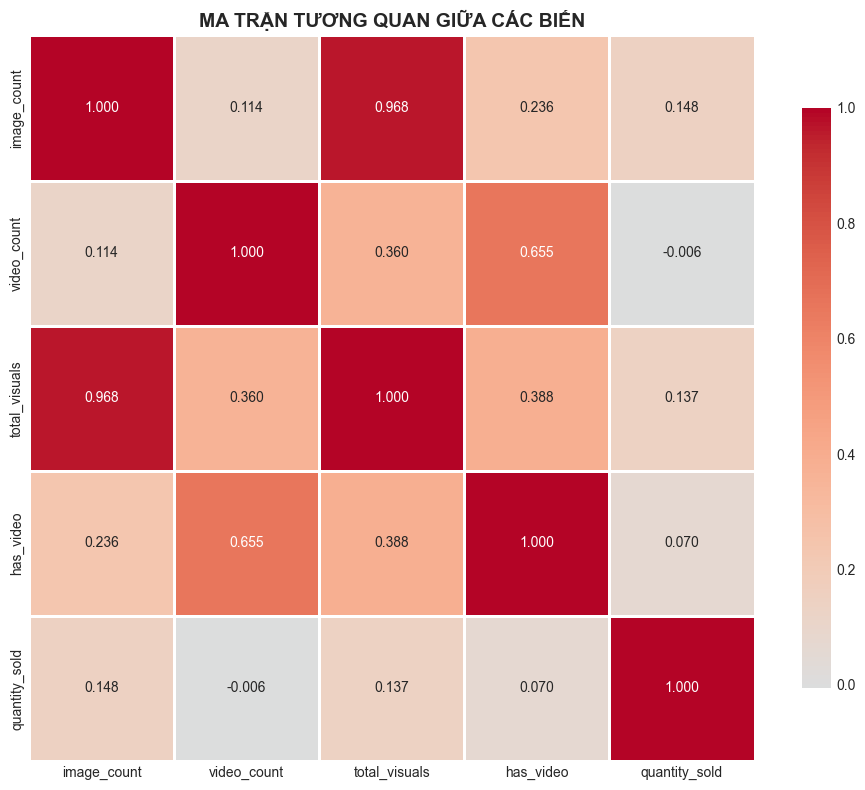

In [3]:

print("\n" + "="*80)
print("TƯƠNG QUAN GIỮA CÁC BIẾN")
print("="*80)

# Tính ma trận tương quan
corr_matrix = df_visual.corr()
print("\n Ma trận tương quan:")
print(corr_matrix.round(3))

# Heatmap tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, cbar_kws={'shrink': 0.8},
            linewidths=1, linecolor='white')
plt.title('MA TRẬN TƯƠNG QUAN GIỮA CÁC BIẾN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



- Không có biến hình ảnh hoặc video nào đạt mức tương quan đáng kể.
- image_count là biến có mức liên hệ cao nhất, nhưng vẫn chỉ r ≈ 0.15 → rất yếu.
- total_visuals cũng có liên hệ cao thứ hai nhưng vẫn còn yếu
- video_count gần như không ảnh hưởng.
- has_video cho thấy có video giúp bán tốt hơn chút, nhưng yếu.

5. Biểu đồ scatter plot giữa từng biến video/hình ảnh với biến mục tiêu quantity sold

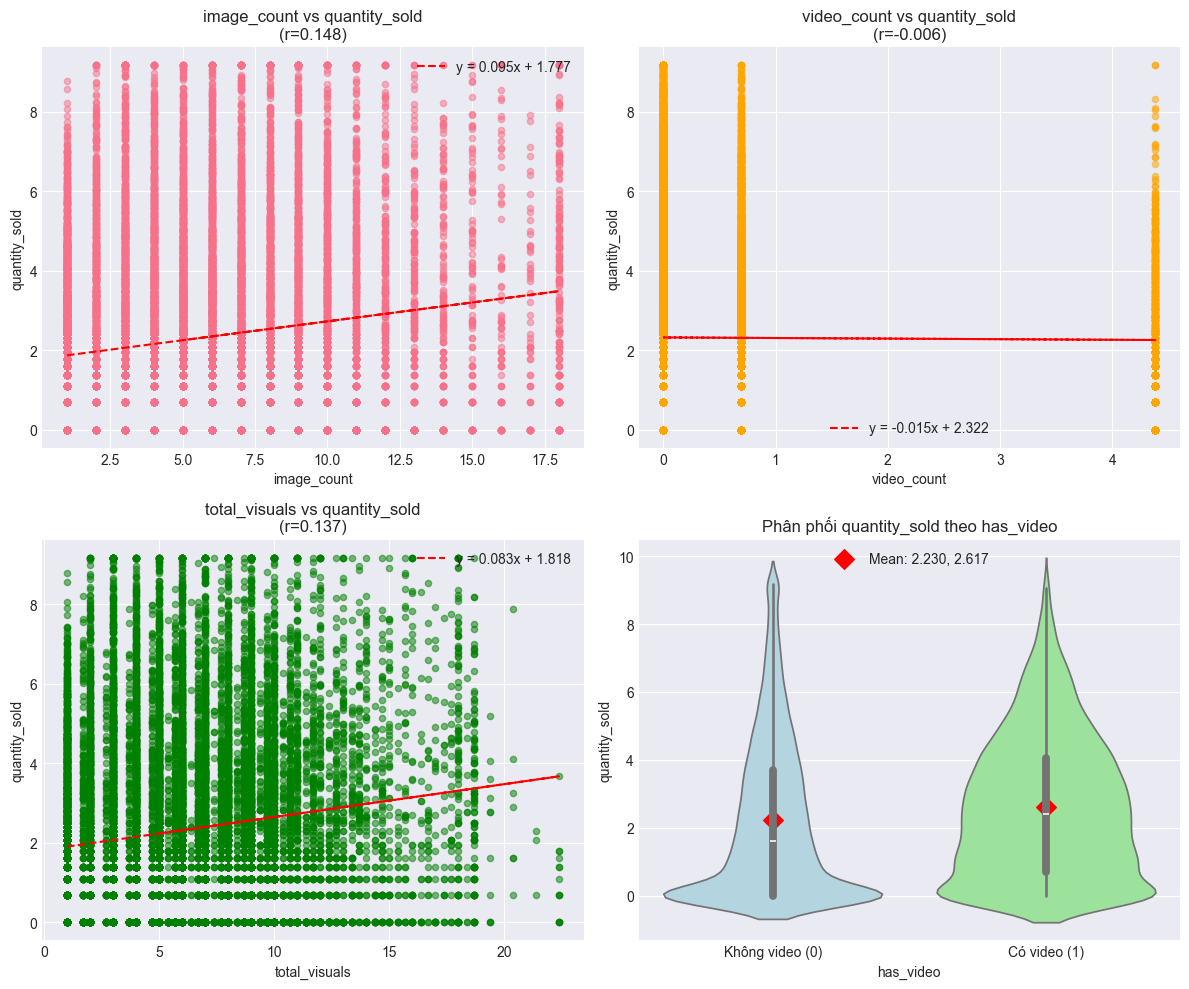

In [5]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter 1: image_count vs quantity_sold
axes[0, 0].scatter(df_visual['image_count'], df_visual['quantity_sold'], alpha=0.5, s=20)
z = np.polyfit(df_visual['image_count'], df_visual['quantity_sold'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df_visual['image_count'], p(df_visual['image_count']), "r--", 
                label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
axes[0, 0].set_xlabel('image_count')
axes[0, 0].set_ylabel('quantity_sold')
axes[0, 0].set_title(f'image_count vs quantity_sold\n(r={corr_matrix.loc["image_count", "quantity_sold"]:.3f})')
axes[0, 0].legend()

# Scatter 2: video_count vs quantity_sold
axes[0, 1].scatter(df_visual['video_count'], df_visual['quantity_sold'], alpha=0.5, s=20, color='orange')
z = np.polyfit(df_visual['video_count'], df_visual['quantity_sold'], 1)
p = np.poly1d(z)
axes[0, 1].plot(df_visual['video_count'], p(df_visual['video_count']), "r--",
                label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
axes[0, 1].set_xlabel('video_count')
axes[0, 1].set_ylabel('quantity_sold')
axes[0, 1].set_title(f'video_count vs quantity_sold\n(r={corr_matrix.loc["video_count", "quantity_sold"]:.3f})')
axes[0, 1].legend()

# Scatter 3: total_visuals vs quantity_sold
axes[1, 0].scatter(df_visual['total_visuals'], df_visual['quantity_sold'], alpha=0.5, s=20, color='green')
z = np.polyfit(df_visual['total_visuals'], df_visual['quantity_sold'], 1)
p = np.poly1d(z)
axes[1, 0].plot(df_visual['total_visuals'], p(df_visual['total_visuals']), "r--",
                label=f'y = {z[0]:.3f}x + {z[1]:.3f}')
axes[1, 0].set_xlabel('total_visuals')
axes[1, 0].set_ylabel('quantity_sold')
axes[1, 0].set_title(f'total_visuals vs quantity_sold\n(r={corr_matrix.loc["total_visuals", "quantity_sold"]:.3f})')
axes[1, 0].legend()

# Violin plot: has_video vs quantity_sold
sns.violinplot(x='has_video', y='quantity_sold', data=df_visual, ax=axes[1, 1], palette=['lightblue', 'lightgreen'])
axes[1, 1].set_xlabel('has_video')
axes[1, 1].set_ylabel('quantity_sold')
axes[1, 1].set_xticklabels(['Không video (0)', 'Có video (1)'])
axes[1, 1].set_title('Phân phối quantity_sold theo has_video')
means = df_visual.groupby('has_video')['quantity_sold'].mean()
axes[1, 1].scatter([0, 1], means, color='red', s=100, marker='D', 
                   label=f'Mean: {means[0]:.3f}, {means[1]:.3f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()




Nhận xét:
(a) image_count → quantity_sold

Hệ số tương quan: r = 0.148 (mức yếu nhưng dương).
Đường hồi quy có độ dốc dương nhẹ, nghĩa là:
→ Khi số lượng hình ảnh tăng lên, lượng bán có xu hướng tăng nhưng mức tăng không mạnh.
→ Hình ảnh có tác động tích cực nhưng yếu.

(b) video_count → quantity_sold

Hệ số tương quan: r = –0.007 (gần bằng 0 và là số r < 0 → không có quan hệ).
Scatter plot cho thấy: hầu hết sản phẩm không có video, nhưng lượng bán phân tán đều → video count không dự đoán được lượng bán.

→ Số lượng video hầu như không ảnh hưởng đến số lượng bán.

(c) total_visuals → quantity_sold

Hệ số tương quan: r = 0.137 > 0 (tích cực nhưng yếu).
Biểu đồ scatter dày, phân tán mạnh → xuất hiện mối quan hệ tuyến tính 
→ Tổng số visual (ảnh + video) có liên hệ với biến mục tiêu nhưng cũng khá yếu

(d) has_video -> quantity_sold
Mean nhóm không video: 0.243
Mean nhóm có video: 0.285
→ Nhóm có video cao hơn một chút, nhưng khác biệt không lớn.

Dạng phân phối:
Hai phân phối gần giống nhau, đều lệch phải mạnh.

=> Việc có video chỉ giúp tăng lượng bán một chút, nhưng không phải yếu tố quyết định.

- Ảnh là yếu tố tác động tốt nhất trong nhóm visual.

- Video tạo thêm niềm tin nhưng không quyết định hành vi mua.

- Người dùng ưu tiên xem nhiều ảnh hơn là video khi ra quyết định.

👉 Visual content không phải yếu tố chính, nhưng là yếu tố phụ trợ quan trọng, giúp tăng khả năng mua hàng thông qua tăng tính minh bạch và niềm tin về sản phẩm.

6. Biểu đồ Scatter Plot giữa 3 biến image_count, quantity sold, has video (has video được biểu diễn thành màu)

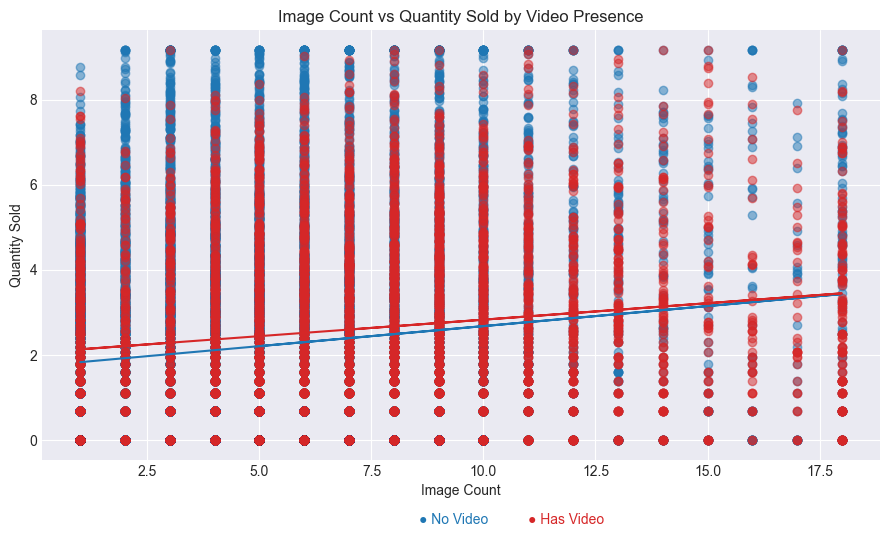

In [ ]:
# Load dữ liệu
df = pd.read_csv("full_data_final.csv")
df = df[["image_count", "quantity_sold", "has_video"]].dropna()

df_no = df[df["has_video"] == 0]
df_yes = df[df["has_video"] == 1]

plt.figure(figsize=(9, 6))

# Scatter
plt.scatter(df_no["image_count"], df_no["quantity_sold"],
            color="tab:blue", alpha=0.5)
plt.scatter(df_yes["image_count"], df_yes["quantity_sold"],
            color="tab:red", alpha=0.5)

# Trend lines
coef_no = np.polyfit(df_no["image_count"], df_no["quantity_sold"], 1)
plt.plot(df_no["image_count"],
         coef_no[0]*df_no["image_count"] + coef_no[1],
         color="tab:blue")

coef_yes = np.polyfit(df_yes["image_count"], df_yes["quantity_sold"], 1)
plt.plot(df_yes["image_count"],
         coef_yes[0]*df_yes["image_count"] + coef_yes[1],
         color="tab:red")

# Gán nhãn
plt.xlabel("Image Count")
plt.ylabel("Quantity Sold")
plt.title("Image Count vs Quantity Sold by Video Presence")

# Chú thích
plt.text(
    0.45, -0.15, "● No Video",
    transform=plt.gca().transAxes,
    color="tab:blue",
    fontsize=10
)

plt.text(
    0.58, -0.15, "● Has Video",
    transform=plt.gca().transAxes,
    color="tab:red",
    fontsize=10
)

# Chừa không gian bên dưới
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()


- Biểu đồ cho thấy khi sản phẩm có cả hình ảnh và video thì lượt bán ra cao hơn so với sản phẩm có hình ảnh nhưng không có video. Tuy nhiên nhưng khi số lượng hình ảnh nhiều thì có hay không có video cũng không còn quan trọng, điều đó được biểu hiện qua 2 đường xu hướng gần như trùng nhau.